# **BFP_PE Synthesis Flow — TSMC28 HPC+**

Drives Yosys synthesis of all Chisel-generated `BFP_PE` designs under `generated/fused_dot/` using the TSMC28 HPC+ standard-cell library.

**Before running on the student server, ensure:**
```bash
export PDK_ROOT=/users/micas/micasusr/design/tsmc28hpcplus
export PDK=tsmc28hpcplus
```

### **Helper: write-template magic**

In [19]:
import os, re, time
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from pandas import DataFrame
pd.set_option('display.precision', 4)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 90)

In [20]:
from IPython.core.magic import register_line_cell_magic

@register_line_cell_magic
def writetemplate(line, cell):
    with open(line, 'w') as f:
        f.write(cell.format(**globals()))

### **Project-specific Environment Variables**

- `CONFIG` selects one configuration under `generated/fused_dot/` for the **single-run** flow.
- Batch flow auto-discovers **all** configs from `generated/fused_dot/`.
- `CLOCK_PERIOD` is not used by Yosys ABC, but kept for documentation.
- Library paths are absolute and match the student-server TSMC28 installation.

In [21]:
# ── Single-config selector (used only in Section 1) ───────────────────────────
CONFIG = "INT8_E2M1_UE8M0_vec1"

DESIGN_NAME  = "BFP_PE"
CLOCK_PERIOD = 1.0   # ns (1 GHz) — documentation only for Yosys flow

# ── Paths ─────────────────────────────────────────────────────────────────────
# BACKEND_DIR = directory where this notebook lives
BACKEND_DIR = os.path.dirname(os.path.abspath("__file__"))
REPO_ROOT   = os.path.abspath(os.path.join(BACKEND_DIR, "..", "..", ".."))

# RTL directory containing all generated configurations
FUSED_DOT_DIR = os.path.join(REPO_ROOT, "hw", "chisel_acc", "generated", "fused_dot")

RTL_PATH = os.path.join(FUSED_DOT_DIR, CONFIG, f"{DESIGN_NAME}.sv")

# ── Tool paths ────────────────────────────────────────────────────────────────
CONDA_PREFIX = os.environ.get(
    "CONDA_PREFIX",
    "/esat/micas_raid/users/h05d4a_students/conda-env"
)
YOSYS = os.path.join(CONDA_PREFIX, "bin", "yosys")

# ── TSMC28 HPC+ library paths (student server) ────────────────────────────────
_TSMC28_LIB_DIR = (
    "/users/micas/micas/design/tsmc28hpcplus/standard_cell_libraries/"
    "tcbn28hpcplusbwp30p140-set/tcbn28hpcplusbwp30p140_190a_FE/TSMCHOME/"
    "digital/Front_End/timing_power_noise/NLDM/tcbn28hpcplusbwp30p140_180a"
)
LIBERTY_FILE = f"{_TSMC28_LIB_DIR}/tcbn28hpcplusbwp30p140tt0p9v25c.lib"
GENLIB_FILE  = os.path.join(BACKEND_DIR, "tsmc28hpcplus_tt0p9v25c.genlib")

# ── Run tag ───────────────────────────────────────────────────────────────────
TAG      = "{}_{}".format(time.strftime("%y%m%d-%H%M%S", time.localtime()), CONFIG)
CORE_NUM = os.popen("nproc").read().strip()

# ── Conversion constant ───────────────────────────────────────────────────────
UM2_TO_MM2 = 1e-6  # 1 µm² = 1e-6 mm²

print(f"CONFIG        : {CONFIG}")
print(f"RTL_PATH      : {RTL_PATH}")
print(f"FUSED_DOT_DIR : {FUSED_DOT_DIR}")
print(f"YOSYS         : {YOSYS}  (exists: {os.path.isfile(YOSYS)})")
print(f"LIBERTY_FILE  : {LIBERTY_FILE}")
print(f"GENLIB_FILE   : {GENLIB_FILE}")
print(f"TAG           : {TAG}")
print(f"RTL exists    : {os.path.isfile(RTL_PATH)}")

CONFIG        : INT8_E2M1_UE8M0_vec1
RTL_PATH      : /users/students/r0927191/Documents/chisel/SNAX-Chisel/hw/chisel_acc/generated/fused_dot/INT8_E2M1_UE8M0_vec1/BFP_PE.sv
FUSED_DOT_DIR : /users/students/r0927191/Documents/chisel/SNAX-Chisel/hw/chisel_acc/generated/fused_dot
YOSYS         : /esat/micas_raid/users/h05d4a_students/conda-env/bin/yosys  (exists: True)
LIBERTY_FILE  : /users/micas/micas/design/tsmc28hpcplus/standard_cell_libraries/tcbn28hpcplusbwp30p140-set/tcbn28hpcplusbwp30p140_190a_FE/TSMCHOME/digital/Front_End/timing_power_noise/NLDM/tcbn28hpcplusbwp30p140_180a/tcbn28hpcplusbwp30p140tt0p9v25c.lib
GENLIB_FILE   : /users/students/r0927191/Documents/chisel/SNAX-Chisel/hw/chisel_acc/Backend/tsmc28hpcplus_tt0p9v25c.genlib
TAG           : 260408-193343_INT8_E2M1_UE8M0_vec1
RTL exists    : True


---
## Section 1 — Single-Config Synthesis

### Step 1: Generate the Yosys synthesis script

In [22]:
%%writetemplate synth.ys

# Yosys synthesis script — TSMC28 HPC+ (NLDM TT 0.9V 25C)
# CONFIG : {CONFIG}
# RTL    : {RTL_PATH}

# ── Read & elaborate ──────────────────────────────────────────────────────────
read_verilog -sv {RTL_PATH}
hierarchy -check -top {DESIGN_NAME}

# ── Synthesis ─────────────────────────────────────────────────────────────────
synth -top {DESIGN_NAME}

# ── Technology mapping ────────────────────────────────────────────────────────
dfflibmap -liberty {LIBERTY_FILE}
abc -genlib {GENLIB_FILE}

# ── Clean up ──────────────────────────────────────────────────────────────────
clean

# ── Reports ───────────────────────────────────────────────────────────────────
tee -o ./runs/{TAG}/reports/area.rpt stat -liberty {LIBERTY_FILE}

# ── Write netlist ─────────────────────────────────────────────────────────────
write_verilog -noattr ./runs/{TAG}/results/{DESIGN_NAME}_netlist.v

### Step 2: Run Yosys

In [23]:
os.makedirs(f"runs/{TAG}/reports", exist_ok=True)
os.makedirs(f"runs/{TAG}/results", exist_ok=True)
!{YOSYS} -l runs/{TAG}_yosys.log synth.ys


 /----------------------------------------------------------------------------\
 |                                                                            |
 |  yosys -- Yosys Open SYnthesis Suite                                       |
 |                                                                            |
 |  Copyright (C) 2012 - 2020  Claire Xenia Wolf <claire@yosyshq.com>         |
 |                                                                            |
 |  Permission to use, copy, modify, and/or distribute this software for any  |
 |  purpose with or without fee is hereby granted, provided that the above    |
 |  copyright notice and this permission notice appear in all copies.         |
 |                                                                            |
 |  THE SOFTWARE IS PROVIDED "AS IS" AND THE AUTHOR DISCLAIMS ALL WARRANTIES  |
 |  WITH REGARD TO THIS SOFTWARE INCLUDING ALL IMPLIED WARRANTIES OF          |
 |  MERCHANTABILITY AND FITNESS. IN NO 

### Step 3: Area Analysis (single config)

In [24]:
def parse_area_rpt(rpt_path):
    """Parse a Yosys `stat -liberty` area report.

    Returns
    -------
    top_area_um2 : float or None
    submodules   : dict[str, float]  — {module_name: area_um2}
                   Does NOT include the top module itself.
    """
    with open(rpt_path) as f:
        content = f.read()

    # Top module total area (hierarchical)
    top_area = None
    top_name = None
    m = re.search(r"Chip area for top module '\\(.+?)': ([\d.]+)", content)
    if m:
        top_name = m.group(1)
        top_area = float(m.group(2))

    # Per-module (submodule) areas — exclude the top module entry
    submodules = {}
    for m in re.finditer(r"Chip area for module '\\(.+?)': ([\d.]+)", content):
        name = m.group(1)
        if name != top_name:
            submodules[name] = float(m.group(2))

    return top_area, submodules


top_area, submodules = parse_area_rpt(f"./runs/{TAG}/reports/area.rpt")

print(f"Config : {CONFIG}")
print(f"Top    : {top_area:>12.3f} µm²   {top_area * UM2_TO_MM2:.8f} mm²")
print()
print("Submodules (sorted by area desc):")
for mod, area in sorted(submodules.items(), key=lambda x: -x[1]):
    print(f"  {mod:<55s}  {area:>10.3f} µm²   {area * UM2_TO_MM2:.8f} mm²")

Config : INT8_E2M1_UE8M0_vec1
Top    :      741.762 µm²   0.00074176 mm²

Submodules (sorted by area desc):
  FP32Adder                                                   500.724 µm²   0.00050072 mm²
  ScaleToFP32_INT8_x_E2M1_UE8M0                                65.520 µm²   0.00006552 mm²
  ScaleAddition_INT8_to_E2M1_scale_UE8M0                       52.668 µm²   0.00005267 mm²
  CustomOperator_INT8_to_E2M1                                  23.184 µm²   0.00002318 mm²


---
## Section 2 — Batch Synthesis (all configs)

Auto-discovers every sub-directory under `generated/fused_dot/` that contains a `BFP_PE.sv` file, runs Yosys synthesis for each, parses the hierarchical area report, and collects results.

In [25]:
# ── Discover all configurations ───────────────────────────────────────────────
ALL_CONFIGS = sorted(
    d.name
    for d in Path(FUSED_DOT_DIR).iterdir()
    if d.is_dir() and (d / f"{DESIGN_NAME}.sv").exists()
)

print(f"Found {len(ALL_CONFIGS)} configurations in {FUSED_DOT_DIR}:")
for cfg in ALL_CONFIGS:
    print(f"  {cfg}")

Found 181 configurations in /users/students/r0927191/Documents/chisel/SNAX-Chisel/hw/chisel_acc/generated/fused_dot:
  E4M3_E2M1_UE2M6_vec16
  E4M3_E2M1_UE2M6_vec32
  E4M3_E2M1_UE2M6_vec4
  E4M3_E2M1_UE4M4_vec16
  E4M3_E2M1_UE4M4_vec32
  E4M3_E2M1_UE4M4_vec4
  E4M3_E2M1_UE6M2_vec16
  E4M3_E2M1_UE6M2_vec32
  E4M3_E2M1_UE6M2_vec4
  E4M3_E2M1_UE8M0_vec16
  E4M3_E2M1_UE8M0_vec32
  E4M3_E2M1_UE8M0_vec4
  E4M3_E2M3_UE2M6_vec16
  E4M3_E2M3_UE2M6_vec32
  E4M3_E2M3_UE2M6_vec4
  E4M3_E2M3_UE4M4_vec16
  E4M3_E2M3_UE4M4_vec32
  E4M3_E2M3_UE4M4_vec4
  E4M3_E2M3_UE6M2_vec16
  E4M3_E2M3_UE6M2_vec32
  E4M3_E2M3_UE6M2_vec4
  E4M3_E2M3_UE8M0_vec16
  E4M3_E2M3_UE8M0_vec32
  E4M3_E2M3_UE8M0_vec4
  E4M3_E3M2_UE2M6_vec16
  E4M3_E3M2_UE2M6_vec32
  E4M3_E3M2_UE2M6_vec4
  E4M3_E3M2_UE4M4_vec16
  E4M3_E3M2_UE4M4_vec32
  E4M3_E3M2_UE4M4_vec4
  E4M3_E3M2_UE6M2_vec16
  E4M3_E3M2_UE6M2_vec32
  E4M3_E3M2_UE6M2_vec4
  E4M3_E3M2_UE8M0_vec16
  E4M3_E3M2_UE8M0_vec32
  E4M3_E3M2_UE8M0_vec4
  E4M3_E4M3_UE2M6_vec16
  E4M3_

In [26]:
# ── Batch synthesis loop ──────────────────────────────────────────────────────
os.makedirs("runs", exist_ok=True)
batch_raw = []   # list of (cfg, cfg_tag, area_rpt_path, ok)

for cfg in ALL_CONFIGS:
    cfg_tag     = "{}_{}".format(time.strftime("%y%m%d-%H%M%S", time.localtime()), cfg)
    rtl         = os.path.join(FUSED_DOT_DIR, cfg, f"{DESIGN_NAME}.sv")
    reports_dir = f"./runs/{cfg_tag}/reports"
    results_dir = f"./runs/{cfg_tag}/results"
    area_rpt    = f"{reports_dir}/area.rpt"

    os.makedirs(reports_dir, exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

    ys = (
        f"# Yosys synthesis — {cfg}\n"
        f"read_verilog -sv {rtl}\n"
        f"hierarchy -check -top {DESIGN_NAME}\n"
        f"synth -top {DESIGN_NAME}\n"
        f"dfflibmap -liberty {LIBERTY_FILE}\n"
        f"abc -genlib {GENLIB_FILE}\n"
        f"clean\n"
        f"tee -o {area_rpt} stat -liberty {LIBERTY_FILE}\n"
        f"write_verilog -noattr {results_dir}/{DESIGN_NAME}_netlist.v\n"
    )
    ys_file = f"synth_{cfg}.ys"
    with open(ys_file, "w") as fh:
        fh.write(ys)

    print(f"[{ALL_CONFIGS.index(cfg)+1:3d}/{len(ALL_CONFIGS)}] {cfg} ... ", end="", flush=True)
    ret = os.system(f"{YOSYS} -l runs/{cfg_tag}_yosys.log {ys_file} > /dev/null 2>&1")

    ok = ret == 0 and os.path.exists(area_rpt)
    print("OK" if ok else f"FAIL (ret={ret})")
    batch_raw.append((cfg, cfg_tag, area_rpt, ok))

print("\nBatch synthesis complete.")

[  1/181] E4M3_E2M1_UE2M6_vec16 ... OK
[  2/181] E4M3_E2M1_UE2M6_vec32 ... OK
[  3/181] E4M3_E2M1_UE2M6_vec4 ... OK
[  4/181] E4M3_E2M1_UE4M4_vec16 ... OK
[  5/181] E4M3_E2M1_UE4M4_vec32 ... OK
[  6/181] E4M3_E2M1_UE4M4_vec4 ... OK
[  7/181] E4M3_E2M1_UE6M2_vec16 ... OK
[  8/181] E4M3_E2M1_UE6M2_vec32 ... OK
[  9/181] E4M3_E2M1_UE6M2_vec4 ... OK
[ 10/181] E4M3_E2M1_UE8M0_vec16 ... OK
[ 11/181] E4M3_E2M1_UE8M0_vec32 ... OK
[ 12/181] E4M3_E2M1_UE8M0_vec4 ... OK
[ 13/181] E4M3_E2M3_UE2M6_vec16 ... OK
[ 14/181] E4M3_E2M3_UE2M6_vec32 ... OK
[ 15/181] E4M3_E2M3_UE2M6_vec4 ... OK
[ 16/181] E4M3_E2M3_UE4M4_vec16 ... OK
[ 17/181] E4M3_E2M3_UE4M4_vec32 ... OK
[ 18/181] E4M3_E2M3_UE4M4_vec4 ... OK
[ 19/181] E4M3_E2M3_UE6M2_vec16 ... OK
[ 20/181] E4M3_E2M3_UE6M2_vec32 ... OK
[ 21/181] E4M3_E2M3_UE6M2_vec4 ... OK
[ 22/181] E4M3_E2M3_UE8M0_vec16 ... OK
[ 23/181] E4M3_E2M3_UE8M0_vec32 ... OK
[ 24/181] E4M3_E2M3_UE8M0_vec4 ... OK
[ 25/181] E4M3_E3M2_UE2M6_vec16 ... OK
[ 26/181] E4M3_E3M2_UE2M6_vec32 .

### Parse area reports & build results tables

In [27]:
# ── Parse every area report ───────────────────────────────────────────────────
summary_rows      = []   # one row per config
hierarchical_rows = []   # one row per (config, module)

for cfg, cfg_tag, area_rpt, ok in batch_raw:
    if not ok or not os.path.exists(area_rpt):
        summary_rows.append({
            "config": cfg, "tag": cfg_tag,
            "top_area_um2": None, "top_area_mm2": None, "status": "FAIL"
        })
        continue

    top_um2, subs = parse_area_rpt(area_rpt)

    summary_rows.append({
        "config":       cfg,
        "tag":          cfg_tag,
        "top_area_um2": top_um2,
        "top_area_mm2": top_um2 * UM2_TO_MM2 if top_um2 is not None else None,
        "status":       "OK" if top_um2 is not None else "NO_AREA",
    })

    # Top module
    hierarchical_rows.append({
        "config":    cfg,
        "module":    DESIGN_NAME,
        "is_top":    True,
        "area_um2":  top_um2,
        "area_mm2":  top_um2 * UM2_TO_MM2 if top_um2 is not None else None,
    })

    # Submodules
    for mod, area_um2 in sorted(subs.items(), key=lambda x: -x[1]):
        hierarchical_rows.append({
            "config":   cfg,
            "module":   mod,
            "is_top":   False,
            "area_um2": area_um2,
            "area_mm2": area_um2 * UM2_TO_MM2,
        })

df_summary = DataFrame(summary_rows)
df_hier    = DataFrame(hierarchical_rows)

print("=== Summary (top-level area per config) ===")
print(df_summary[["config", "top_area_um2", "top_area_mm2", "status"]].to_string(index=False))

=== Summary (top-level area per config) ===
               config  top_area_um2  top_area_mm2 status
E4M3_E2M1_UE2M6_vec16     19405.134        0.0194     OK
E4M3_E2M1_UE2M6_vec32     38710.350        0.0387     OK
 E4M3_E2M1_UE2M6_vec4      4926.222        0.0049     OK
E4M3_E2M1_UE4M4_vec16     17752.014        0.0178     OK
E4M3_E2M1_UE4M4_vec32     35404.110        0.0354     OK
 E4M3_E2M1_UE4M4_vec4      4512.942        0.0045     OK
E4M3_E2M1_UE6M2_vec16     16334.766        0.0163     OK
E4M3_E2M1_UE6M2_vec32     32569.614        0.0326     OK
 E4M3_E2M1_UE6M2_vec4      4158.630        0.0042     OK
E4M3_E2M1_UE8M0_vec16     15238.062        0.0152     OK
E4M3_E2M1_UE8M0_vec32     30376.206        0.0304     OK
 E4M3_E2M1_UE8M0_vec4      3884.454        0.0039     OK
E4M3_E2M3_UE2M6_vec16     21096.558        0.0211     OK
E4M3_E2M3_UE2M6_vec32     42093.198        0.0421     OK
 E4M3_E2M3_UE2M6_vec4      5349.078        0.0053     OK
E4M3_E2M3_UE4M4_vec16     19130.958        0

### Export results to CSV

In [28]:
# ── Save CSVs ─────────────────────────────────────────────────────────────────
RESULTS_CSV_DIR = os.path.join(BACKEND_DIR, "runs")
os.makedirs(RESULTS_CSV_DIR, exist_ok=True)

batch_ts = time.strftime("%y%m%d-%H%M%S", time.localtime())

# 1. Summary: one row per config, top area only
summary_csv = os.path.join(RESULTS_CSV_DIR, f"{batch_ts}_area_summary.csv")
df_summary[["config", "top_area_um2", "top_area_mm2", "status", "tag"]].to_csv(
    summary_csv, index=False
)
print(f"Summary CSV  : {summary_csv}")

# 2. Hierarchical: one row per (config, module) — top + submodules
hier_csv = os.path.join(RESULTS_CSV_DIR, f"{batch_ts}_area_hierarchical.csv")
df_hier[["config", "module", "is_top", "area_um2", "area_mm2"]].to_csv(
    hier_csv, index=False
)
print(f"Hierarchical CSV: {hier_csv}")

print(f"\nTotal configs synthesised : {len(df_summary)}")
print(f"Successful               : {(df_summary['status'] == 'OK').sum()}")
print(f"Failed                   : {(df_summary['status'] != 'OK').sum()}")

Summary CSV  : /users/students/r0927191/Documents/chisel/SNAX-Chisel/hw/chisel_acc/Backend/runs/260408-195534_area_summary.csv
Hierarchical CSV: /users/students/r0927191/Documents/chisel/SNAX-Chisel/hw/chisel_acc/Backend/runs/260408-195534_area_hierarchical.csv

Total configs synthesised : 181
Successful               : 181
Failed                   : 0


### Quick visualisation — top area vs. configuration

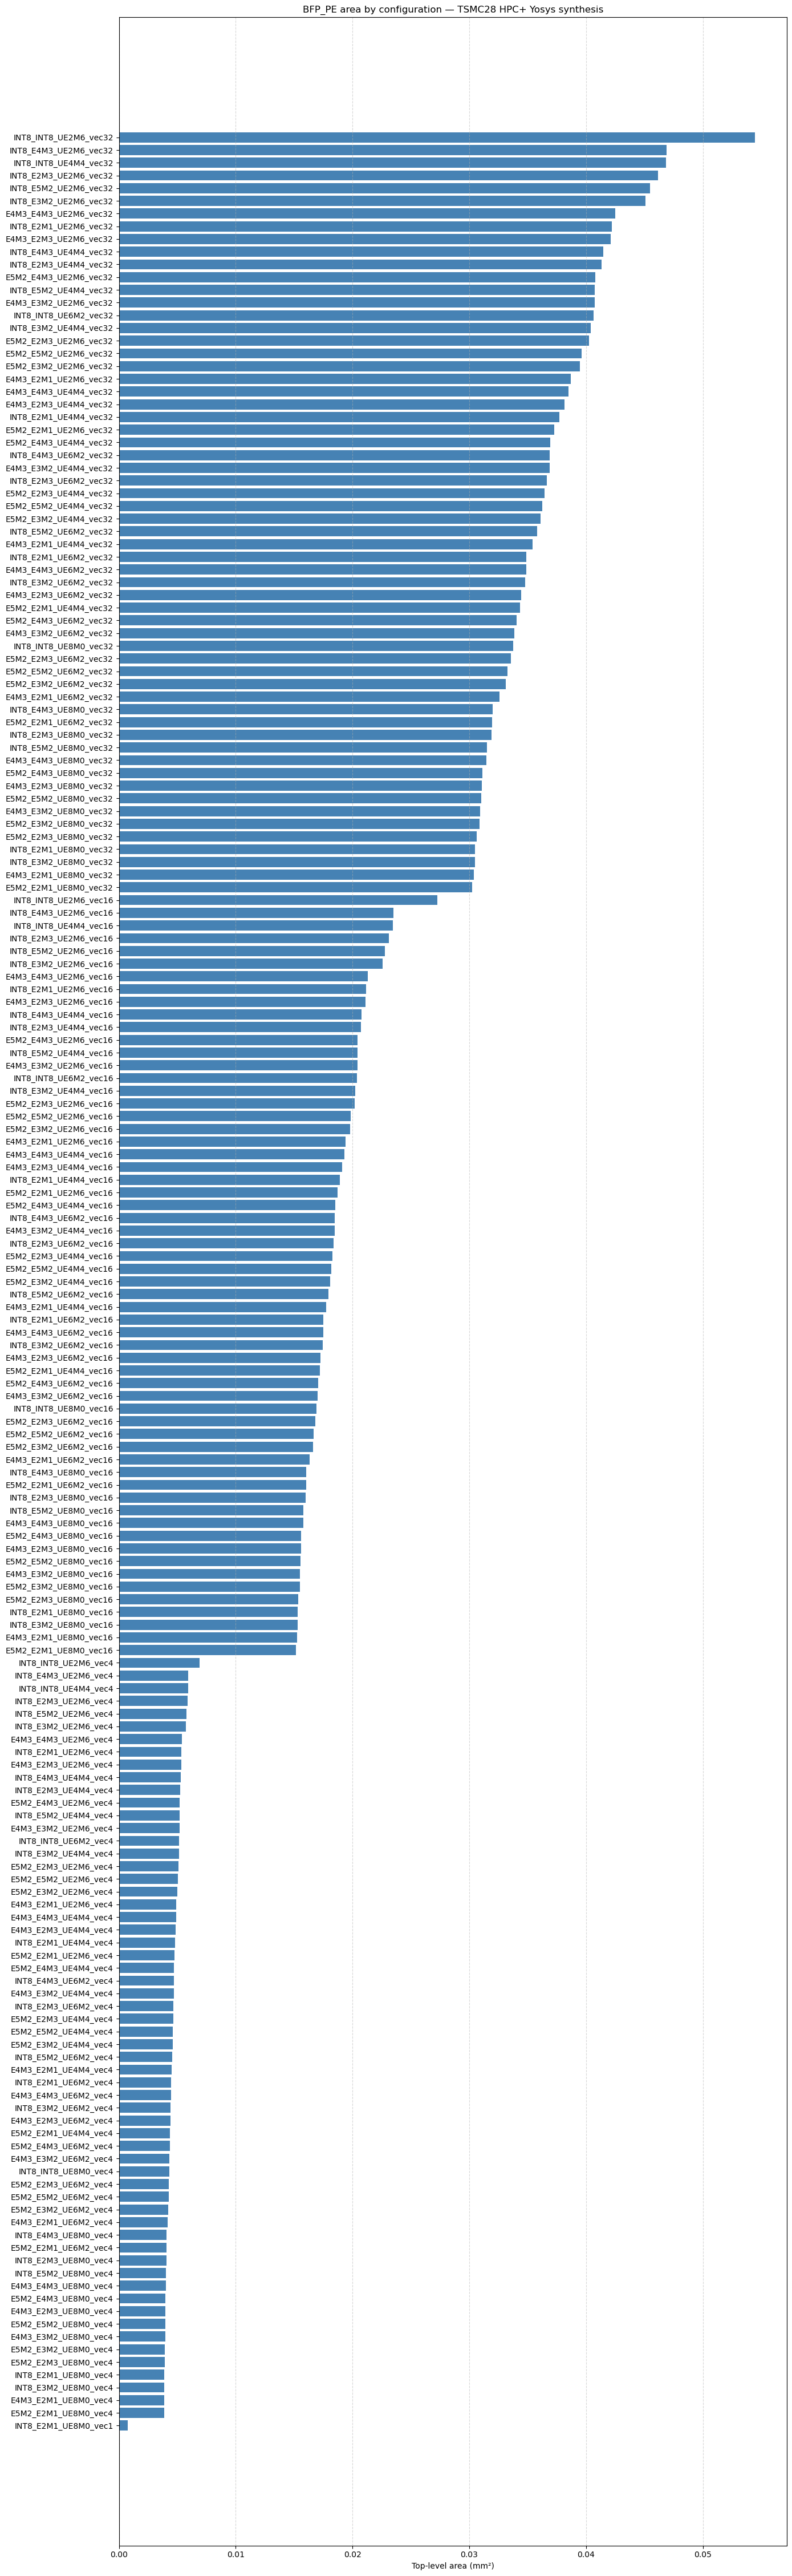

In [29]:
df_ok = df_summary[df_summary["status"] == "OK"].sort_values("top_area_mm2")

fig, ax = plt.subplots(figsize=(14, max(4, len(df_ok) * 0.25)))
ax.barh(df_ok["config"], df_ok["top_area_mm2"], color="steelblue")
ax.set_xlabel("Top-level area (mm²)")
ax.set_title("BFP_PE area by configuration — TSMC28 HPC+ Yosys synthesis")
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_CSV_DIR, f"{batch_ts}_area_chart.png"), dpi=150)
plt.show()